In [26]:
import marimo as mo
from FEM_classes_3D import Node, TrussElement, FEMSystem
from plot_functions import plot_mode_shape
from truss_config import trelica
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dinâmica Estrutural e Análise Modal de Treliças (MEF)

A análise dinâmica de uma estrutura começa pela compreensão de suas propriedades intrínsecas: os modos de vibrar e suas frequências naturais. O Método dos Elementos Finitos (MEF) discretiza o domínio contínuo da treliça em um número finito de graus de liberdade, transformando as equações diferenciais parciais em um sistema algébrico matricial.

A equação de movimento para o sistema em vibração livre e não amortecida é governada pelo equilíbrio entre as forças inerciais e as forças elásticas:

$$[M]\{\ddot{U}\} + [K]\{U\} = \{0\}$$

Onde $[M]$ é a matriz de massa global e $[K]$ é a matriz de rigidez global. Assumindo que a estrutura vibra de forma harmônica simples sincronizada, os deslocamentos podem ser descritos como $\{U\} = \{\phi\}e^{i\omega t}$. Substituindo essa solução na equação de movimento, chegamos ao problema de autovalores:

$$([K] - \omega^2[M])\{\phi\} = \{0\}$$

A resolução deste sistema nos fornece duas informações físicas fundamentais:
1. **Autovalores ($\omega^2$):** Representam as frequências circulares naturais ao quadrado. A partir delas, obtemos as frequências naturais em Hertz ($f = \omega / 2\pi$), que indicam as frequências de ressonância da estrutura.
2. **Autovetores ($\{\phi\}$):** Representam as Formas Modais, ou seja, a configuração geométrica relativa que a estrutura assume ao vibrar em cada uma dessas frequências naturais.

Importamos todas as classes criadas, a configuração da treliça e nosso helper script para plotagem, o OpenSees e algumas outras bibliotecas necessárias para a análise.

## Analise modal

Vamos primeiro montar o sistema no solver desenvolvido para o trabalho e fazer a análise modal do sistema.

In [27]:
# Quantidade de modos a serem calculados
numModos = list(trelica.elem.keys())[-1]

nodes: list[Node] = []
for id, (x, y, z) in trelica.nodes.items():
    nodes.append(Node(id=id, x=x, y=y, z=z))

elems: list[TrussElement] = []
for id, (no_i, no_j) in trelica.elem.items():
    elems.append(
        TrussElement(
            id=id,
            node_i=nodes[no_i],
            node_j=nodes[no_j],
            E=trelica.material.modElast,
            A=trelica.material.A,
            rho=trelica.material.dens,
        )
    )

bcs = [
    nodes[0].dof_x,  # Apoio fixo: Trava X
    nodes[0].dof_y,  # Apoio fixo: Trava Y
    nodes[5].dof_y,  # Apoio móvel: Trava Y
]

# Força todos os nós a não saírem do plano 2D
for no in nodes:
    bcs.append(no.dof_z)

sistema = FEMSystem(nodes=nodes, elements=elems, boundarycond=bcs)

freqNaturais, formasModais = sistema.solve_modal_analysis(num_modes=numModos)

Para atestar a validade física e consistência matemática do solver implementado, os resultados do problema de autovalores são comparados aos de um software comercial consolidado (OpenSees).

In [28]:
# Limpa a memória de análises anteriores
ops.wipe()

# Modelo básico, 3 Dimensões (X e Y), 3 Graus de Liberdade por nó
ops.model("basic", "-ndm", 2, "-ndf", 2)

# Instanciamento dos nós
# OpenSees exige que os IDs sejam maiores que zero, por isso id+1
for n_id, (n_x, n_y, _) in trelica.nodes.items():
    ops.node(n_id + 1, n_x, n_y)

# Condições de contorno
# Sintaxe: ops.fix(node_tag, dof_x, dof_y) -> 1 = Travado, 0 = Livre
# Apoio Fixo: Trava X e Y
ops.fix(0 + 1, 1, 1)

# Apoio Móvel: Trava apenas Y
ops.fix(5 + 1, 0, 1)

# MATERIAL E PROPRIEDADES
mat_tag = 1
# Cria um material elástico linear usando o Módulo de Young configurado no truss_config.py
ops.uniaxialMaterial("Elastic", mat_tag, trelica.material.modElast)

# ELEMENTOS (Treliça)
# Para o elemento de treliça o OpenSees pede a densidade em Kg/m ao invés de Kg/m^3
densidadeLinear = trelica.material.dens * trelica.material.A

for e_id, (n_i, n_j) in trelica.elem.items():
    # Sintaxe: ops.element('Truss', ele_tag, node_i, node_j, Area, mat_tag, '-rho', densidade linear, '-cMass', True(1) ou False(0))
    # A flag '-cMass 1' força o uso da Matriz de Massa Consistente no lugar da de massa concentrada
    ops.element(
        "Truss",
        e_id + 1,
        n_i + 1,
        n_j + 1,
        trelica.material.A,
        mat_tag,
        "-rho",
        densidadeLinear,
        "-cMass",
        1,
    )

# Calcula os autovalores a partir do problema de autovalor e autovetor
lambdas = ops.eigen(numModos)

freqNaturaisOpenSees = np.array([])
total_dofs = len(trelica.nodes) * 3
formasModaisOpenSees = np.zeros([total_dofs, numModos])
for i, lam in enumerate(lambdas):
    # Calcula a frequência natural e à adiciona ao vetor de frequências naturais
    omega = np.sqrt(lam)
    freq_Hz = omega / (2 * np.pi)
    freqNaturaisOpenSees = np.append(freqNaturaisOpenSees, freq_Hz)

    # Extrai os deslocamentos nó a nó para montar o vetor completo
    for n_id in trelica.nodes.keys():
        if n_id != 0:
            # Tags no OpenSees são +1. Modos no OpenSees começam em 1 (i + 1)
            # Omitindo o DOF, ele retorna a lista completa: [ux, uy]
            deslocamentos = ops.nodeEigenvector(n_id + 1, i + 1)

            # Mapeando para os índices "espaçados" da sua classe 3D (X, Y, Z)
            dof_x = n_id * 3
            dof_y = n_id * 3 + 1

            # Inserindo os valores retornados na matriz global
            formasModaisOpenSees[dof_x, i] = deslocamentos[0]  # ux
            formasModaisOpenSees[dof_y, i] = deslocamentos[1]  # uy
            # O dof_z (n_id * 3 + 2) automaticamente continua sendo 0

In [29]:
seletor_escala = mo.ui.slider(
    start=0.01,
    stop=100,
    step=0.5,
    value=1,
    label="**Selecione a escala de visualização:**",
    show_value=True,
)

seletor_modo = mo.ui.slider(
    start=1,
    stop=numModos,
    step=1,
    value=1,
    label="**Selecione o Modo de Vibração:**",
    show_value=True,
)

seletor_visibilidade_custom = mo.ui.checkbox(True, label="Solver Custom")
seletor_visibilidade_opensees = mo.ui.checkbox(True, label="OpenSees")

controles = mo.vstack(
    [
        seletor_escala,
        seletor_modo,
        mo.hstack(
            [seletor_visibilidade_custom, seletor_visibilidade_opensees],
            justify="start",
        ),
    ]
)

## Visualização das Formas Modais

Fisicamente, as formas modais não possuem uma amplitude absoluta (elas não estão em milímetros ou metros). Elas representam apenas a proporção de deslocamento entre os nós da estrutura. Uma forma modal indica que, quando o nó A se desloca 1 unidade para cima, o nó B necessariamente se desloca 0.5 unidades para baixo, por exemplo.

Para efeitos de visualização, aplicamos um fator de escala arbitrário. O objetivo desta representação é permitir a inspeção visual dos eixos de flexão e identificar quais nós permanecem parados (nós modais) durante a vibração em uma frequência específica.

_FlexContainerHtml()
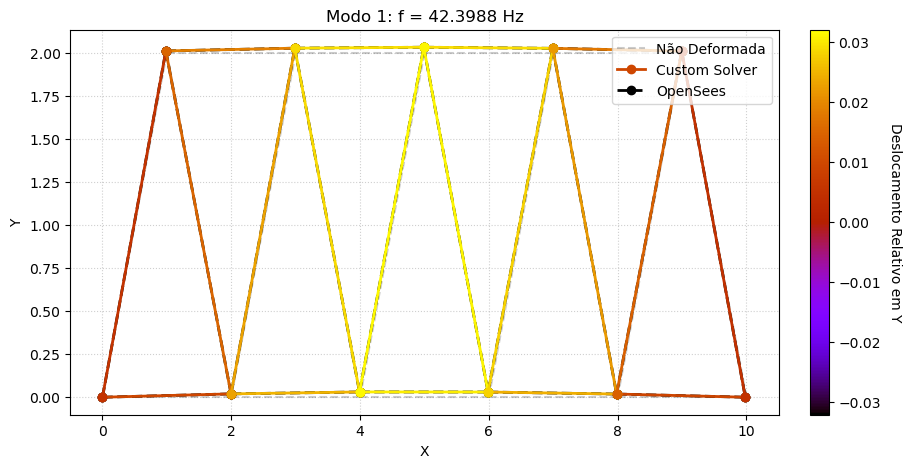

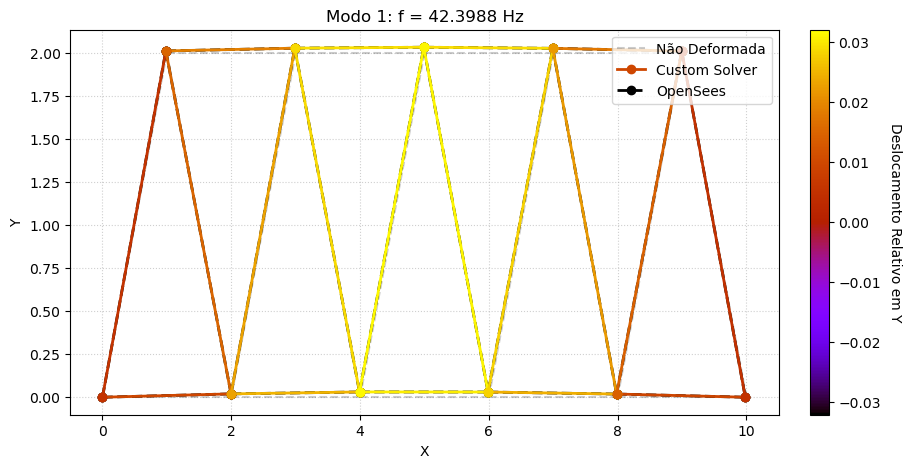

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
idx = seletor_modo.value - 1

exibir_custom = seletor_visibilidade_custom.value

# 1. Plotar o Custom Solver
if exibir_custom:
    plot_mode_shape(
        sistema,
        freqNaturais,
        formasModais,
        axs=ax,
        mode_index=idx,
        scale=seletor_escala.value,
        label="Custom Solver",
        use_hue=True,
    )

# 2. Plotar o OpenSees
if seletor_visibilidade_opensees.value:
    # Se o Custom também estiver visível, usamos o OpenSees como contorno (tracejado preto)
    # Se apenas o OpenSees estiver visível, aplicamos o Hue a ele
    usar_hue_ops = not exibir_custom
    cor_ops = "black" if exibir_custom else "red"
    estilo_ops = "--" if exibir_custom else "-"
    fundo_ops = not exibir_custom

    plot_mode_shape(
        sistema,
        freqNaturaisOpenSees,
        formasModaisOpenSees,
        axs=ax,
        mode_index=idx,
        scale=seletor_escala.value,
        label="OpenSees",
        color=cor_ops,
        linestyle=estilo_ops,
        use_hue=usar_hue_ops,
        plot_original=fundo_ops,
    )

    # fig.savefig(
    #     f"docs_trelica/docs/assets/comparativo_forma_modal_{idx}.png",
    #     dpi=400,
    #     bbox_inches="tight",
    # )

mo.vstack([controles, mo.as_html(fig)])

In [31]:
erros_abs = np.abs(freqNaturais - freqNaturaisOpenSees)

# Proteção contra divisão por zero
erros_perc = np.where(freqNaturais != 0, (erros_abs / freqNaturais) * 100, 0.0)

# 2. Cria o DataFrame do Pandas
df_comparativo = pd.DataFrame(
    {
        "Modo": np.arange(1, numModos + 1, step=1),
        "Custom Solver [Hz]": np.round(freqNaturais, 4),
        "OpenSees [Hz]": np.round(freqNaturaisOpenSees, 4),
        "Erro Absoluto [Hz]": erros_abs,
        "Erro Relativo [%]": erros_perc,
    }
)

tabela_markdown = df_comparativo.to_markdown(index=False)

# 2. Monta o texto forçando linhas em branco (\n\n) entre os elementos
pagina_mkdocs = (
    f"{tabela_markdown}\n\n"
    f"> **Erro Máximo Encontrado:** `{np.max(erros_abs):.2e} Hz`\n\n"
)

# 3. Escreve no arquivo
with open(
    "docs_trelica/docs/snippets/resultados_opensees.md",
    "w",
    encoding="utf-8",
) as arquivo:
    arquivo.write(pagina_mkdocs)

In [32]:
# Range Slider para a Frequência (Min e Max)
seletor_faixa_freq = mo.ui.range_slider(
    start=0.2,
    stop=1000.0,
    step=1.0,
    value=[0.2, 200.0],
    label="**Faixa de Frequência [Hz]:**",
)

# Nós com GDLs livres
opcoes_nos = {}
for n in sistema.nodes:
    if n.dof_x in sistema.free_dofs_array:
        opcoes_nos[f"Nó {n.id} (Direção X)"] = n.dof_x
    if n.dof_y in sistema.free_dofs_array:
        opcoes_nos[f"Nó {n.id} (Direção Y)"] = n.dof_y

seletor_gdl = mo.ui.multiselect(
    options=opcoes_nos,
    value=[list(opcoes_nos.keys())[5]],
    label="**Selecione os Nós para Monitorar:**",
)

seletor_validacao_opensees = mo.ui.checkbox(
    value=False, label="Plotar validação do OpenSees?"
)

# Empilha os controles na tela
controles_harm = mo.hstack(
    [seletor_faixa_freq, seletor_gdl, seletor_validacao_opensees]
)

In [33]:
opcoes_nos_carga = {f"Nó {n.id}": n.id for n in sistema.nodes}

# 1. Seletor Mestre de Quantidade
seletor_qtd_cargas = mo.ui.number(
    start=1,
    stop=10,
    step=1,
    value=1,
    label="**Quantidade de Forças Simultâneas:**",
)

In [34]:
# 2. Construtor Dinâmico de Entradas
def criar_painel_cargas(qtd):
    md_text = ""
    controles = {}

    for i in range(qtd):
        # Cria chaves únicas para cada carga (ex: no_0, dir_0, mag_0)
        k_no, k_dir, k_mag = f"no_{i}", f"dir_{i}", f"mag_{i}"

        # Cria os controles no dicionário
        controles[k_no] = mo.ui.dropdown(options=opcoes_nos_carga, value="Nó 3")
        controles[k_dir] = mo.ui.dropdown(
            options={"Eixo X": "X", "Eixo Y": "Y"}, value="Eixo Y"
        )
        controles[k_mag] = mo.ui.number(value=1000.0, step=100.0)

        # Monta o texto Markdown chamando as chaves
        md_text += f"**Carga {i + 1}:** &nbsp; Nó: {{{k_no}}} &nbsp;|&nbsp; Direção: {{{k_dir}}} &nbsp;|&nbsp; Magnitude: {{{k_mag}}} N \n\n"

    # Retorna um ÚNICO objeto reativo oficial do Marimo contendo tudo!
    return mo.md(md_text).batch(**controles)


# Cria o componente perfeitamente reativo
cargas_reativas = criar_painel_cargas(seletor_qtd_cargas.value)

# Empilha e mostra na tela
painel_motor = mo.vstack(
    [
        mo.md("Configuração das cargas"),
        seletor_qtd_cargas,
        cargas_reativas,
    ]
)

In [35]:
if not seletor_gdl.value:
    raise ValueError("Selecione pelo menos um nó para visualizar o gráfico.")

# ==========================================
# APLICANDO MÚLTIPLAS CARGAS
# ==========================================
sistema.nodal_loads = {}

# Extrai o mega-dicionário (ex: {'no_0': 3, 'dir_0': 'Y', 'mag_0': 1000.0, 'no_1': ...})
valores_carga = cargas_reativas.value

# Descobre quantas cargas existem dividindo por 3 (já que cada carga tem 3 parâmetros)
qtd_cargas_aplicadas = len(valores_carga) // 3

for ii in range(qtd_cargas_aplicadas):
    sistema.apply_load(
        node_id=valores_carga[f"no_{ii}"],
        direction=valores_carga[f"dir_{ii}"][-1],  # O [-1] pega a letra X ou Y
        magnitude=valores_carga[f"mag_{ii}"],
    )
# ==========================================

## Análise Harmônica (Resposta em Frequência)

Enquanto a análise modal estuda a estrutura isolada, a Análise Harmônica investiga como a estrutura se comporta ao ser submetida a uma carga externa, como o funcionamento de um motor desbalanceado.

Para que a resposta da estrutura não tenda ao infinito ao atingir a ressonância, é necessário introduzir a dissipação de energia. Fisicamente, utilizamos o modelo de amortecimento proporcional, que assume que a matriz de amortecimento $[C]$ é uma combinação linear da massa e da rigidez do sistema:

$$[C] = \alpha[M] + \beta[K]$$

Os coeficientes $\alpha$ e $\beta$ são calibrados para garantir uma taxa de amortecimento crítico (geralmente em torno de $2\%$) ancorada nas duas primeiras frequências naturais mais relevantes para o fenômeno.

### O Problema Transiente (Método de Integração Passo a Passo)

Softwares orientados a análises sísmicas (como o OpenSees) geralmente não resolvem o problema harmônico de forma direta. Eles solucionam a equação diferencial completa no domínio do tempo utilizando algoritmos de integração numérica (como o método de Newmark):

$$[M]\{\ddot{U}\} + [C]\{\dot{U}\} + [K]\{U\} = \{F(t)\}$$

Quando a força senoidal inicia em $t=0$, a resposta física da estrutura é a superposição de dois regimes:
1. **Regime Transiente:** A vibração natural da estrutura gerada pelo "choque" inicial de ligar o motor, que decai exponencialmente devido ao amortecimento.
2. **Regime Permanente:** A vibração forçada na exata frequência de excitação do motor.

Para extrair a amplitude pura (sem o batimento causado pelo transiente ou deslocamentos de nível), o solver no tempo precisa simular dezenas de ciclos até que a parcela transiente dissipe, para então extrair a amplitude "Pico a Pico" do regime permanente. Por varrer frequências de forma iterativa no tempo, este método tem um custo computacional extremamente elevado.

In [36]:
def get_opensees_harmonic_multi(
    frequencias_hz,
    valores_carga,
    no_monitorado: int,
    dir_monitorada: str,
    alpha_rayleigh: float = 0.0,
    beta_rayleigh: float = 0.0,
):
    amplitudes = np.zeros(len(frequencias_hz))
    dof_ops = 1 if dir_monitorada == "X" else 2
    qtd_cargas = len(valores_carga) // 3

    for i, f in enumerate(frequencias_hz):
        if f <= 0:
            continue

        ops.reset()
        ops.setTime(0.0)

        # Cria uma tag única para esta frequência
        tag_atual = i + 1

        ops.rayleigh(alpha_rayleigh, beta_rayleigh, 0.0, 0.0)

        periodo = 1.0 / f

        ops.timeSeries("Sine", tag_atual, 0.0, 1000.0, periodo)
        ops.pattern("Plain", tag_atual, tag_atual)

        # Aplica TODAS as cargas do painel
        for c in range(qtd_cargas):
            no_c = valores_carga[f"no_{c}"] + 1
            dir_c = valores_carga[f"dir_{c}"][-1]
            mag_c = valores_carga[f"mag_{c}"]

            if dir_c == "X":
                ops.load(no_c, mag_c, 0.0)
            else:
                ops.load(no_c, 0.0, mag_c)

        ops.wipeAnalysis()
        ops.system("ProfileSPD")
        ops.numberer("RCM")
        ops.constraints("Plain")
        ops.test("NormDispIncr", 1.0e-6, 10, 0)
        ops.algorithm("Newton")
        ops.integrator("Newmark", 0.5, 0.25)
        ops.analysis("Transient")

        passos_por_ciclo = 20
        dt = periodo / passos_por_ciclo

        # Garante um tempo bruto suficiente para o "tranco" inicial passar
        # Usa o maior valor entre 20 ciclos ou 2.5 segundos absolutos
        tempo_necessario = max(20 * periodo, 2.5)
        passos_transiente = int(tempo_necessario / dt)

        ops.analyze(passos_transiente, dt)

        # 2. A MÁGICA DO PICO A PICO (Peak-to-Peak)
        # Inicializamos com valores extremos (infinito)
        disp_max = -float("inf")
        disp_min = float("inf")

        # Varre exatamente 1 ciclo do regime permanente
        for _ in range(passos_por_ciclo):
            ops.analyze(1, dt)
            disp = ops.nodeDisp(no_monitorado + 1, dof_ops)  # SEM o abs() aqui!

            # Registra a crista e o vale da onda
            if disp > disp_max:
                disp_max = disp
            if disp < disp_min:
                disp_min = disp

        # A amplitude real é a metade da distância do vale até a crista
        amplitudes[i] = (disp_max - disp_min) / 2.0

        # Faxina das tags
        ops.remove("loadPattern", tag_atual)
        ops.remove("timeSeries", tag_atual)

    return amplitudes

### Função de Resposta em Frequência (FRF) via Matriz de Impedância

Diferente da integração no tempo, o solver desenvolvido mapeia a resposta da estrutura operando puramente no domínio da frequência. Substituindo a força harmônica e a solução permanente na equação de movimento, eliminamos a variável "tempo" e geramos a matriz de Impedância Dinâmica Complexa $[H]$:

$$[H] = [K] - \omega^2[M] + i\omega[C]$$

O sistema resolvido passa a ser algebricamente simples: $[H]\{U\} = \{F\}$. A parte imaginária ($i\omega[C]$) impõe o atraso de fase na resposta da estrutura (a energia dissipada).

**A Escala em Decibéis (dB):**
Escolheu-se representar Função de Resposta em Frequência (FRF) é apresentada na escala logarítmica de decibéis em relação a uma referência ($1\text{ mm}$).

$$L_{dB} = 20 \log_{10}\left(\frac{A}{A_{ref}}\right)$$

_FlexContainerHtml()
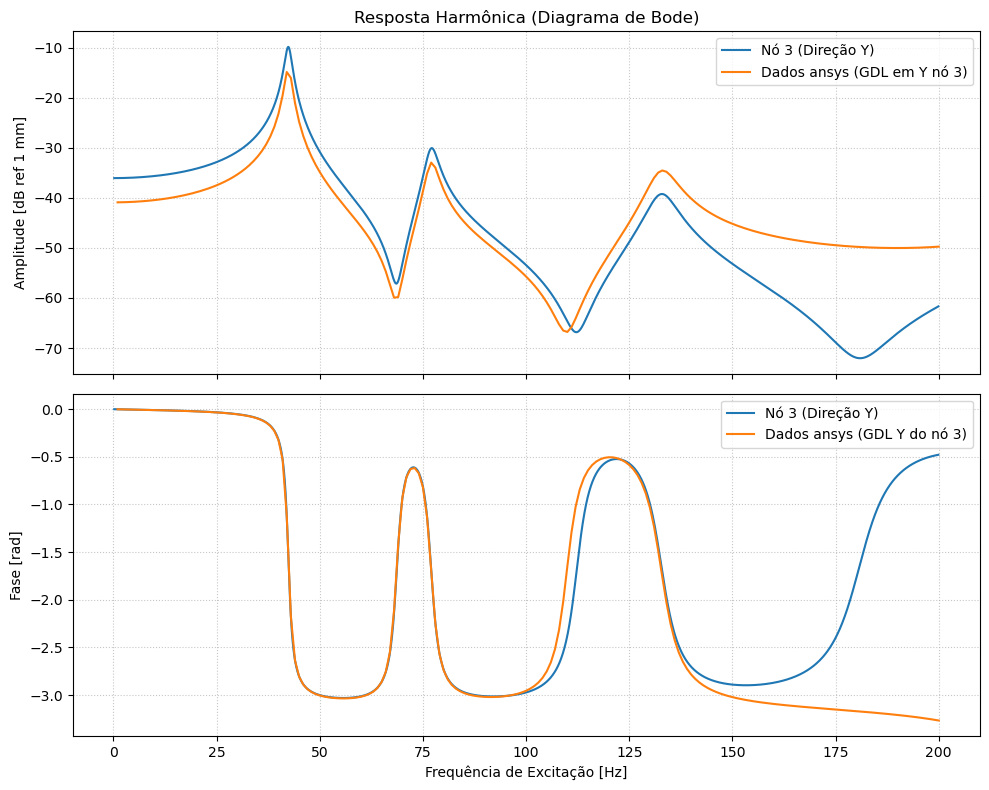

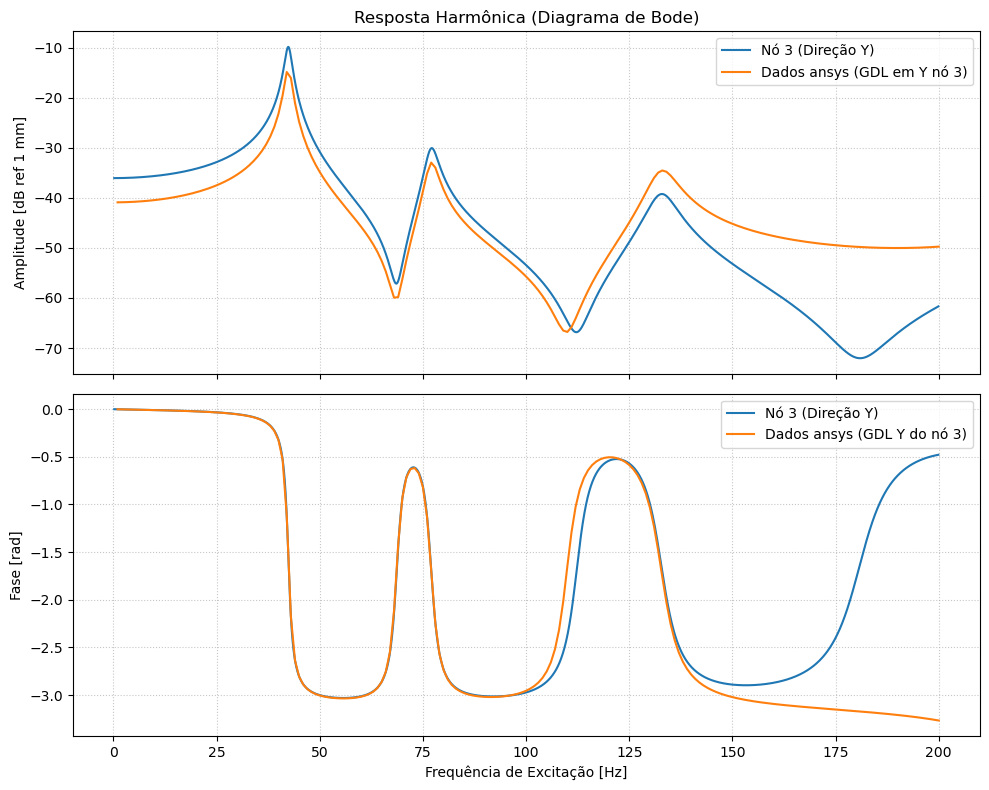

In [37]:
df_ansys = pd.read_csv("dados_ansys.csv")

f_min, f_max = seletor_faixa_freq.value
if f_min == f_max:
    f_max += 1

# Inverte o dicionário para mapear GDL -> Nome
# Exemplo: Transforma { "Nó 3 (Direção Y)": 10 } em { 10: "Nó 3 (Direção Y)" }
gdl_para_nome = {valor: chave for chave, valor in opcoes_nos.items()}

vet_freq = np.arange(f_min, f_max, step=0.1, dtype="float64")
vet_freq_ops = np.arange(f_min, f_max, step=1, dtype="float64")

# 2. Calcular Alpha e Beta automaticamente para 2% de amortecimento
xi = 0.02

# Converte as duas primeiras frequências do seu solver para rad/s
w1 = 2 * np.pi * freqNaturais[0]
w2 = 2 * np.pi * freqNaturais[1]

# Calcula os parâmetros de Rayleigh
alpha_calc = 2 * xi * (w1 * w2) / (w1 + w2)
beta_calc = 2 * xi / (w1 + w2)

analiseHarmonica = sistema.solve_harmonic_analysis(
    vet_freq, alpha_rayleigh=alpha_calc, beta_rayleigh=beta_calc
)

# 1. Cria DOIS subplots empilhados (2 linhas, 1 coluna), compartilhando o eixo X
fig2, (ax_mag, ax_fase) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 8), sharex=True
)

for gdl in seletor_gdl.value:
    # O resultado bruto é um número complexo
    resposta_complexa = analiseHarmonica[gdl, :]

    # ==========================================
    # CÁLCULO DA MAGNITUDE (dB)
    # ==========================================
    amplitude_m = np.abs(resposta_complexa)
    A_ref = 1e-3
    amplitude_m_segura = np.maximum(amplitude_m, 1e-12)
    amplitude_dB = 20 * np.log10(amplitude_m_segura / A_ref)

    # ==========================================
    # CÁLCULO DA FASE (Graus)
    # ==========================================

    fase_rad = np.angle(resposta_complexa)

    # A mágica acontece aqui: desenrola os saltos de 2*pi
    fase_rad_continua = np.unwrap(fase_rad)

    nome_da_curva = gdl_para_nome.get(gdl, f"GDL {gdl}")

    # Plota nos respectivos eixos
    ax_mag.plot(vet_freq, amplitude_dB, label=nome_da_curva)
    ax_fase.plot(vet_freq, fase_rad_continua, label=nome_da_curva)

    if seletor_validacao_opensees.value:
        no_str = nome_da_curva.split(" ")[1]
        dir_str = nome_da_curva[-2]

        amp_ops_m = get_opensees_harmonic_multi(
            frequencias_hz=vet_freq_ops,
            valores_carga=valores_carga,
            no_monitorado=int(no_str),
            dir_monitorada=dir_str,
            alpha_rayleigh=alpha_calc,
            beta_rayleigh=beta_calc,
        )

        amp_ops_segura = np.maximum(amp_ops_m, 1e-12)
        amp_ops_dB = 20 * np.log10(amp_ops_segura / A_ref)

        # O tracejado do OpenSees vai APENAS no gráfico de magnitude
        ax_mag.plot(
            vet_freq_ops,
            amp_ops_dB,
            color="black",
            linestyle="--",
            alpha=0.7,
            label=f"OpenSees ({nome_da_curva})",
        )


ax_mag.plot(
    df_ansys["FREQ"],
    20 * np.log10(df_ansys["AMPLITUDE"] / A_ref),
    label="Dados ansys (GDL em Y nó 3)",
)
ax_fase.plot(
    df_ansys["FREQ"],
    np.unwrap(np.deg2rad(df_ansys["PHASE"])),
    label="Dados ansys (GDL Y do nó 3)",
)
# ==========================================
# FORMATAÇÃO DO GRÁFICO DE MAGNITUDE
# ==========================================
ax_mag.set_title("Resposta Harmônica (Diagrama de Bode)")
ax_mag.set_ylabel("Amplitude [dB ref 1 mm]")
ax_mag.grid(True, which="both", linestyle=":", alpha=0.7)
ax_mag.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0))

# ==========================================
# FORMATAÇÃO DO GRÁFICO DE FASE
# ==========================================
ax_fase.set_xlabel("Frequência de Excitação [Hz]")
ax_fase.set_ylabel("Fase [rad]")
# Força o eixo Y a ter marcações redondas de 90 em 90 graus
ax_fase.grid(True, linestyle=":", alpha=0.7)
ax_fase.legend()

# Ajusta os espaçamentos para os textos não se sobreporem
fig2.tight_layout()

# fig2.savefig(
#     "docs_trelica/docs/assets/comparativo_frf.png", dpi=400, bbox_inches="tight"
# )

mo.vstack(
    [
        painel_motor,
        controles_harm,
        mo.as_html(fig2),
        mo.md(f"Alpha e Beta calculados {alpha_calc}, {beta_calc}"),
    ]
)

O método utilizando OpenSees produziu resultados de baixa qualidade, o que já era esperado. Por isso, introduziu-se uma nova validação utilizando o Ansys Mechanical APDL. A convergência para frequências até 150 Hz foi excelente, em especial a fase. Após este ponto as duas curvas divergiram. Ainda não foram feitas análises mais aprofundadas do por que isso pode ter ocorrido e nem se é um efeito espúrio desta banda de frequências.